In [1]:
!pip install arch

Defaulting to user installation because normal site-packages is not writeable


In [2]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
import warnings
from statsmodels.stats.diagnostic import het_arch
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.engine import get_metrics

In [3]:
warnings.filterwarnings("ignore")  # Ignore warnings for cleaner output

In [4]:
df = pd.read_csv(r'../data/processed/cleaned_featured_data.csv', parse_dates=['observation_date'], index_col='observation_date')
df

,DHHNGSP,is_outlier,month,day_of_week,quarter,year,is_winter,rolling_mean_7,lag_1,lag_2,lag_3,Rolling_Std_7,Stationary_Target
observation_date,,,,,,,,,,,,,
2021-07-13,3.78,False,7,1,3,2021,0,NaN,NaN,NaN,NaN,NaN,3.78
2021-07-14,3.80,False,7,2,3,2021,0,NaN,3.78,NaN,NaN,NaN,3.80
2021-07-15,3.68,False,7,3,3,2021,0,NaN,3.80,NaN,NaN,NaN,3.68
2021-07-16,3.70,False,7,4,3,2021,0,NaN,3.68,NaN,NaN,NaN,3.70
2021-07-19,3.75,False,7,0,3,2021,0,NaN,3.70,NaN,NaN,NaN,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-07,3.13,False,7,1,3,2026,0,3.299643,3.29,3.26,3.10,0.076871,3.13
2026-07-08,3.13,False,7,2,3,2026,0,3.271071,3.13,3.33,3.13,0.097978,3.13
2026-07-09,3.17,False,7,3,3,2026,0,3.246786,3.13,3.34,3.04,0.099108,3.17


In [5]:
# Prepare Returns for GARCH Model
returns = 100 * df['DHHNGSP'].pct_change().dropna()  # Calculate daily returns and drop NaN values

In [6]:
arch_test_stat, arch_p_value, _, _ = het_arch(returns)
print(f"ARCH-LM test statistic: {arch_test_stat:.4f}, p-value: {arch_p_value:.4f}")
if arch_p_value < 0.05:
    print("Reject H0 -> ARCH effects present -> GARCH modeling is justified.")
else:
    print("Fail to reject H0 -> little evidence of ARCH effects.")

ARCH-LM test statistic: 3.4408, p-value: 0.9691
Fail to reject H0 -> little evidence of ARCH effects.


In [7]:
# fit GARCH(1, 1) model
print("Fitting GARCH(1, 1) model...")
train_size = int(len(returns) * 0.9)
returns_train, returns_test = returns[:train_size], returns[train_size:]

garch_model = arch_model(returns_train, vol='Garch', p=1, q=1)  

garch_fit = garch_model.fit(disp='off') # disp='off' suppresses the output of the fitting process
print(garch_fit.summary())

Fitting GARCH(1, 1) model...
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                DHHNGSP   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4537.12
Distribution:                  Normal   AIC:                           9082.24
Method:            Maximum Likelihood   BIC:                           9102.50
                                        No. Observations:                 1173
Date:                Sat, Jul 18 2026   Df Residuals:                     1172
Time:                        14:26:06   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.2524      0.643     -0.3

In [8]:
# Forecast volatility over the test horizon
garch_forecast = garch_fit.forecast(horizon=len(returns_test), reindex=False)
forecasted_variance = garch_forecast.variance.values[-1]
forecasted_volatility = np.sqrt(forecasted_variance)

In [9]:
realized_volatility = returns_test.abs().values

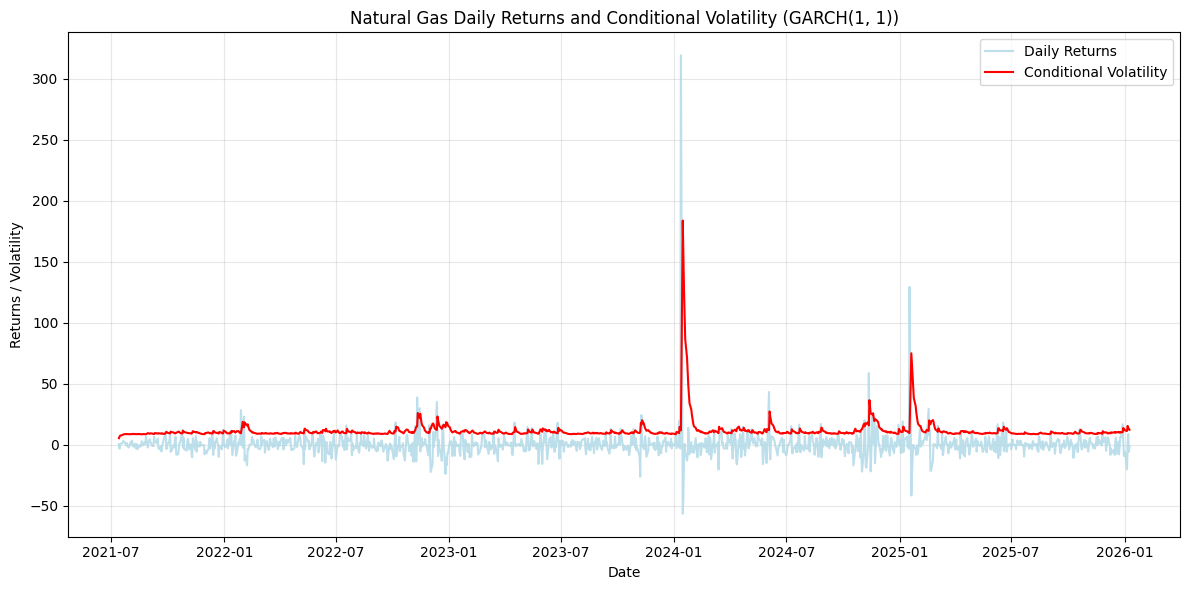

In [11]:
# Visualize volatility clusters
plt.figure(figsize=(12, 6))
plt.plot(returns_train.index, returns_train, label='Daily Returns', color='lightblue', alpha=0.8)
plt.plot(returns_train.index, garch_fit.conditional_volatility, label='Conditional Volatility', color='red', linewidth=1.5)
plt.title('Natural Gas Daily Returns and Conditional Volatility (GARCH(1, 1))')
plt.xlabel('Date')
plt.ylabel('Returns / Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

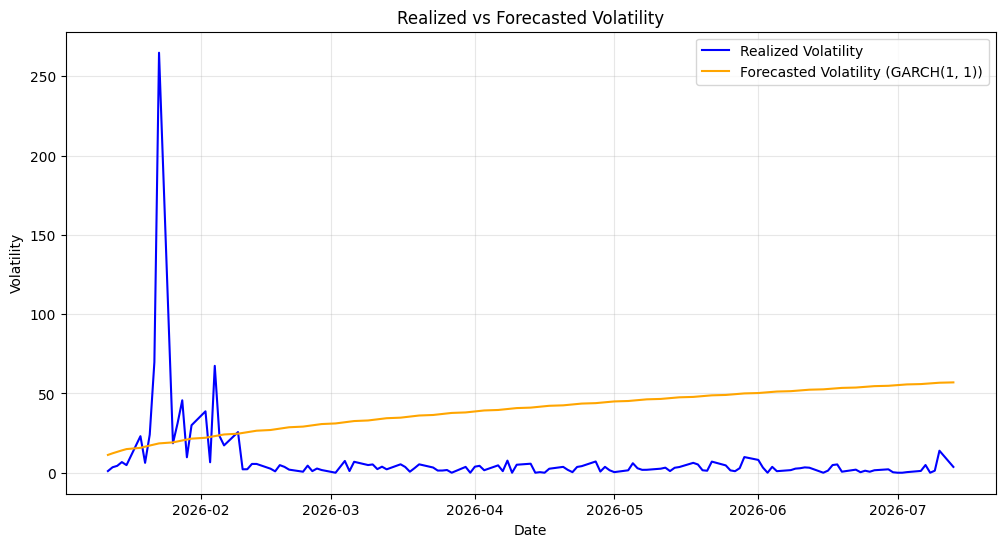

In [12]:
# compare volatility forecasts with actual observed fluctuations
plt.figure(figsize=(12, 6))
plt.plot(returns_test.index, realized_volatility, label='Realized Volatility', color='blue')
plt.plot(returns_test.index, forecasted_volatility, label='Forecasted Volatility (GARCH(1, 1))', color='orange', linewidth=1.5)
plt.title('Realized vs Forecasted Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
vol_metrics = get_metrics(realized_volatility, forecasted_volatility)
print(f"Volatility Forecast Metrics: {vol_metrics}")

Volatility Forecast Metrics: {'MAE': 37.67019786817021, 'RMSE': np.float64(44.16058407934361), 'MAPE': np.float64(inf)}


In [14]:
import json

# Extract metrics from the GARCH fit
garch_metrics = {
    'GARCH(1,1)': {
        'Log-Likelihood': garch_fit.loglikelihood,
        'AIC': garch_fit.aic,
        'BIC': garch_fit.bic,
        'Volatility_Forecast_MAE': vol_metrics['MAE'],
        'Volatility_Forecast_RMSE': vol_metrics['RMSE'],
        'Volatility_Forecast_MAPE': vol_metrics['MAPE']
    }
}

# Save to disk
with open('garch_metrics.json', 'w') as f:
    json.dump(garch_metrics, f)
print("Saved GARCH metrics to garch_metrics.json")

Saved GARCH metrics to garch_metrics.json
